In [1]:
import subprocess
import time

# Start MLflow server in background if not already running
mlflow_server = subprocess.Popen(
    ["uv", "run", "mlflow", "ui", "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)  # Give it time to start up
print("✅ MLflow server started at http://localhost:5000")

✅ MLflow server started at http://localhost:5000


In [2]:
import duckdb
import pandas as pd
import numpy as np
import os
import json
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Point MLflow at your local server
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("olist-customer-segmentation")

print("✅ Setup complete")

d:\Projects\olist-customer-intelligence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete


In [3]:
con = duckdb.connect('../data/olist.db')
print(f"Connected ✅")
print(con.execute("SHOW TABLES").df().to_string())

Connected ✅
                    name
0   category_translation
1              customers
2            geolocation
3            order_items
4          order_payment
5         order_payments
6          order_reviews
7                 orders
8                product
9               products
10               sellers


In [4]:
query = """
WITH
  base_orders AS (
    SELECT
      customers.customer_unique_id,
      orders.order_id,
      orders.order_purchase_timestamp
    FROM
      customers
      LEFT JOIN orders ON customers.customer_id = orders.customer_id
    WHERE
      orders.order_status = 'delivered'
  ),
  customer_metrics AS (
    SELECT
      base_orders.customer_unique_id,
      COUNT(DISTINCT base_orders.order_id) AS total_orders,
      SUM(order_items.price + order_items.freight_value) AS total_spent,
      MAX(base_orders.order_purchase_timestamp) AS last_order_date
    FROM
      base_orders
      LEFT JOIN order_items ON base_orders.order_id = order_items.order_id
    GROUP BY
      base_orders.customer_unique_id
  ),
  final_metrics AS (
    SELECT
      customer_metrics.customer_unique_id,
      customer_metrics.total_orders AS frequency,
      customer_metrics.total_spent AS monetary,
      DATEDIFF (
        'day',
        last_order_date,
        (
          SELECT
            MAX(orders.order_purchase_timestamp)
          FROM
            orders
        )
      ) AS recency_days
    FROM
      customer_metrics
  )
SELECT
  *
FROM
  final_metrics
"""

df = con.execute(query).df()

print(f"Dataset shape: {df.shape}")
print("\nRFM Summary:")
print(df[['recency_days', 'frequency', 'monetary']].describe().round(2))

Dataset shape: (93358, 4)

RFM Summary:
       recency_days  frequency  monetary
count      93358.00   93358.00  93358.00
mean         286.48       1.03    165.17
std          152.60       0.21    226.29
min           49.00       1.00      9.59
25%          163.00       1.00     63.01
50%          267.00       1.00    107.78
75%          395.00       1.00    182.51
max          762.00      15.00  13664.08


In [5]:
# Preprocessing
# 1. Winsorize
for col in ['recency_days', 'frequency', 'monetary']:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

# 2. Logtransforming the skewed column
df['frequency'] = np.log1p(df['frequency'])
df['monetary'] = np.log1p(df['monetary'])

# 3. Standard Scaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['recency_days', 'frequency', 'monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['recency_days', 'frequency', 'monetary'])

In [6]:
print("After Preprocessing:")
print(rfm_scaled.describe().round(2))

After Preprocessing:
       recency_days  frequency  monetary
count      93358.00   93358.00  93358.00
mean          -0.00       0.00      0.00
std            1.00       1.00      1.00
min           -1.56      -0.18     -2.97
25%           -0.81      -0.18     -0.71
50%           -0.13      -0.18     -0.04
75%            0.72      -0.18      0.61
max            2.23       5.69      2.86


In [7]:
# Finding the Right Number of Clusters
cache_file = '../data/kmeans_results.json'
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        result_dict = {int(k): v for k, v in json.load(f).items()}
    print("✅ Loaded from cache")
else:
    result_dict = {}
    for k in tqdm(range(2, 11)):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
        result_dict[k] = {"inertia": kmeans.inertia_, "silhouette_score": silhouette_score(rfm_scaled, kmeans.labels_)}
    print(f"k={k} done")

    with open(cache_file, 'w') as f:
        json.dump(result_dict, f)
    print("✅ saved to cache")

✅ Loaded from cache


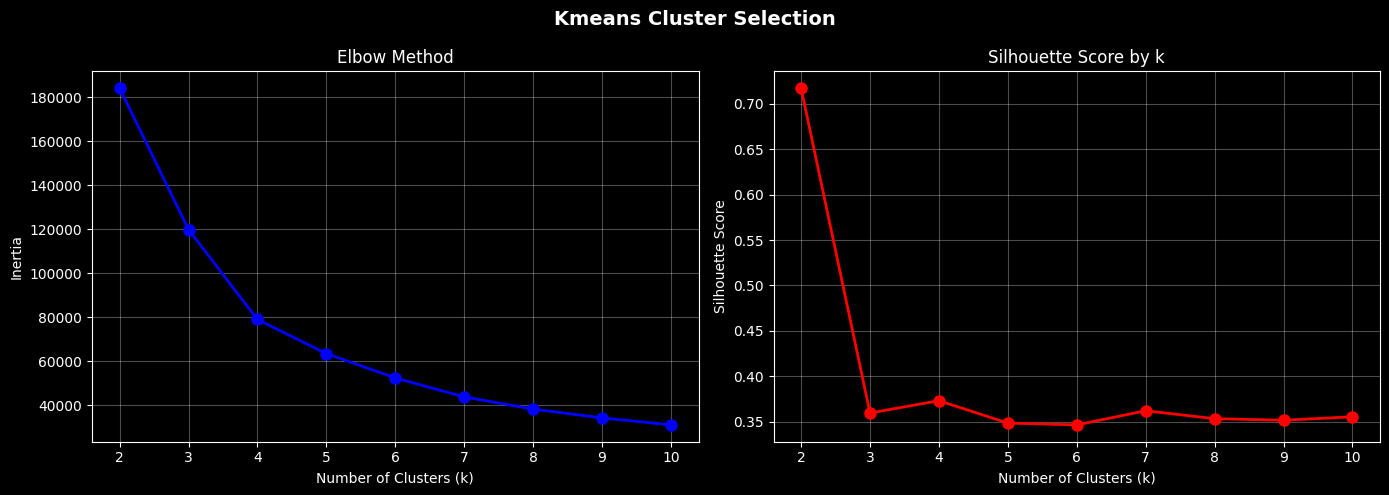

In [8]:
# Plotting the elbow method result
ks = list(result_dict.keys())
inertias = [result_dict[k]['inertia'] for k in ks]
silhouettes = [result_dict[k]['silhouette_score'] for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(ks, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(ks)
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(ks, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xticks(ks)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Kmeans Cluster Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Fitting the final model
k_means_params = {
    "n_clusters": 4,
    "random_state": 42,
    "n_init": 10
}
with mlflow.start_run(run_name="KMeans_v1"):
    kmeans = KMeans(**k_means_params).fit(rfm_scaled)
    df['clusters'] = kmeans.predict(rfm_scaled)
    sil = silhouette_score(rfm_scaled, kmeans.labels_)
    mlflow.log_params(k_means_params)
    mlflow.log_metric("silhouette_score", sil)
    mlflow.sklearn.log_model(kmeans, "clustering_model")
    print(f"Silhouette Score: {sil:.4f}")
    print("\nCluster distribution:")
    print(df['clusters'].value_counts().sort_index())

2026/05/16 11:57:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 11:57:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/16 11:57:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Silhouette Score: 0.3730

Cluster distribution:
clusters
0    28134
1     2801
2    27030
3    35393
Name: count, dtype: int64
🏃 View run KMeans_v1 at: http://localhost:5000/#/experiments/2/runs/e5562d2758944f82946deefabb7ae53f
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [11]:
# Cluster Profiling
# Reload original unscaled RFM data
df_original = con.execute(query).df()

# Add cluster labels
df_original['cluster'] = kmeans.labels_

# Profile clusters on original values
profile = df_original.groupby('cluster')[['recency_days', 'frequency', 'monetary']].mean().round(2)
print(profile)


         recency_days  frequency  monetary
cluster                                   
0              284.86       1.03    164.52
1              286.90       1.03    170.85
2              287.14       1.03    164.84
3              287.23       1.03    165.49


In [13]:
df_original['R_score'] = pd.qcut(df_original['recency_days'],
                                 q=4, labels=[4,3,2,1])
df_original['F_score'] = pd.cut(df_original['frequency'],
                                 bins=[0, 1, 2, 3, float('inf')],
                                 labels=[1, 2, 3, 4])
df_original['M_score'] = pd.qcut(df_original['monetary'],
                                 q=4, labels=[1,2,3,4])

df_original['RFM_score'] = (df_original['R_score'].astype(int) +
                            df_original['F_score'].astype(int) +
                            df_original['M_score'].astype(int))

print(df_original['RFM_score'].describe())
print("\nScore distributions:")
print(df_original['RFM_score'].value_counts().sort_index())

count    93358.000000
mean         6.035830
std          1.631547
min          3.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         12.000000
Name: RFM_score, dtype: float64

Score distributions:
RFM_score
3      5963
4     11761
5     17208
6     22566
7     17204
8     11904
9      6160
10      510
11       60
12       22
Name: count, dtype: int64


Given the output, it is good segmentation mapping:

|RFM Score|Segment Name|Description|
|---------|------------|-----------|
|10-12    |Champions   |Bought recently, buy often, spend the most|
|7-9      |Loyal Customers|Regular buyers, good spender|
|5-6      |Potential Loyalists|Recent Buyers, average spend|
|3-4      |At Risk     |Haven't bought recently, low engagement| 

In [14]:
def assign_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 7:
        return "Loyal Customers"
    elif score >= 5:
        return "Potential Loyalists"
    else:
        return "At Risk"

df_original['segment'] = df_original['RFM_score'].apply(assign_segment)
print(df_original['segment'].value_counts())

segment
Potential Loyalists    39774
Loyal Customers        35268
At Risk                17724
Champions                592
Name: count, dtype: int64


In [18]:
profile = df_original.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(2)

profile['pct_customers'] = (profile['customer_count'] / len(df_original) * 100).round(1)
print(profile.sort_values('avg_monetary', ascending=False))

                     customer_count  avg_recency_days  avg_frequency  \
segment                                                                
Champions                       592            119.44           2.37   
Loyal Customers               35268            183.59           1.06   
Potential Loyalists           39774            310.58           1.01   
At Risk                       17724            442.72           1.00   

                     avg_monetary  pct_customers  
segment                                           
Champions                  437.24            0.6  
Loyal Customers            254.09           37.8  
Potential Loyalists        130.40           42.6  
At Risk                     57.17           19.0  
